In [1]:
import torch
from torch import nn
from torch import optim
from torch.nn.utils import parameters_to_vector
from torch.nn.functional import gelu
# from torchvision import datasets, transforms

# import torchattacks

import numpy as np
import matplotlib.pyplot as plt
# from tqdm import tqdm

from copy import deepcopy
# from itertools import permutations

from helpers import *

# import plotly.express as px
# import plotly.graph_objects as go
# import plotly.io as pio

# import matplotlib.animation as animation
# from matplotlib.colors import ListedColormap

from collections import deque
from torch.utils.data import TensorDataset, DataLoader

from sklearn.linear_model import LogisticRegression


In [141]:
%config InlineBackend.figure_format = 'png'

# Use this for Windows
device = "cuda" if torch.cuda.is_available() else "cpu"

## Functions

In [118]:
def multilabel_hypersphere_data(dim_in, dim_out, N_samples, batch_size, seed):
    """
    Generates N-dimensional hypersphere multilabeling problem data.

    dim_out is a vector of 2 elements.
    Total dim_out classes = the first + second ele

    Unit vector directions are drawn from standard normal in dim_in dimensions.
    Then vectors are scaled uniformly by radius 0 < r < 1.
    Radii are assigned to the first element of dim_out classes with overlapping,
    and the second element of dim_out classes splits the circle in 2n pizza slices,
    then adds new labels on points in every other slice.

    Function returns DataLoader class containing generated samples.
    """
    torch.manual_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)

    u = torch.randn(N_samples, dim_in, generator=g)
    u = u / torch.linalg.vector_norm(u, dim=1).unsqueeze(1)

    angle_rad = torch.atan2(u[:,1], u[:,0])

    r = torch.sqrt(torch.rand(N_samples, generator=g))
    data = u * r.unsqueeze(1) # Scale unit directions by radii

    # Evenly divide radii into classes by cicle and slices, [N_samples,1]
    sections = torch.bucketize(r, torch.linspace(0, 1, dim_out[0]*2)) - 1
    pizza = torch.bucketize(angle_rad, torch.linspace(-torch.pi, torch.pi, dim_out[1]*2+1)) - 1

    labels = torch.zeros(N_samples, dim_out[0] + dim_out[1])

    # Assign labels for the first element of dim_out classes based on sections
    for j in range(max(sections)+1):
        if j%2==0:
            labels[sections == j, j//2] = 1
        elif j//2+1 < dim_out[0]:
            labels[sections == j, j//2] = 1
            labels[sections == j, j//2 + 1] = 1

    # Assign labels for the second element of dim_out classes based on pizza slices
    for i in range(max(pizza)+1):
        if i%2==0:
            labels[:, dim_out[0] + i//2] = (pizza==i).int()
    
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(TensorDataset(data, labels), 
                      batch_size=batch_size, shuffle=True, generator=g)

In [117]:
seed=50
N_samples=100
dim_in=2
dim_out=(3,2)
batch_size=N_samples

torch.manual_seed(seed)
g = torch.Generator()
g.manual_seed(seed)

u = torch.randn(N_samples, dim_in, generator=g)
u = u / torch.linalg.vector_norm(u, dim=1).unsqueeze(1)

angle_rad = torch.atan2(u[:,1], u[:,0])

r = torch.sqrt(torch.rand(N_samples, generator=g))
data = u * r.unsqueeze(1) # Scale unit directions by radii

# Evenly divide radii into classes by cicle and slices, [N_samples,1]
sections = torch.bucketize(r, torch.linspace(0, 1, dim_out[0]*2)) - 1
pizza = torch.bucketize(angle_rad, torch.linspace(-torch.pi, torch.pi, dim_out[1]*2+1)) - 1

labels = torch.zeros(N_samples, dim_out[0] + dim_out[1])

# Assign labels for the first element of dim_out classes based on sections
for j in range(max(sections)+1):
    print(f"print j={j}")
    mask = sections == j
    if j%2==0:
        print(f"if statement: j%2={j%2}")
        print(f"label index j//2={j//2}")
        labels[sections == j, j//2] = 1
    elif j//2+1 < dim_out[0]:
        print("else statement:")
        print(f"label index j//2={j//2}")
        print(f"label index j//2 + 1={j//2+1}")
        labels[sections == j, j//2] = 1
        labels[sections == j, j//2 + 1] = 1

# Assign labels for the second element of dim_out classes based on pizza slices
for i in range(max(pizza)+1):
    if i%2==0:
        labels[:, dim_out[0] + i//2] = (pizza==i).int()

g = torch.Generator()
g.manual_seed(seed)
DataLoader(TensorDataset(data, labels), 
                    batch_size=batch_size, shuffle=True, generator=g)

print j=0
if statement: j%2=0
label index j//2=0
print j=1
else statement:
label index j//2=0
label index j//2 + 1=1
print j=2
if statement: j%2=0
label index j//2=1
print j=3
else statement:
label index j//2=1
label index j//2 + 1=2
print j=4
if statement: j%2=0
label index j//2=2


In [142]:
def get_grid(input_dim, num_points_per_dim=100):
    #Classify on 100^n grid, contrained to a input_dim hypersphere
    n_arrays = [np.linspace(-1.5, 1.5, num_points_per_dim) for _ in range(input_dim)]
    grid = np.meshgrid(*n_arrays, indexing='ij') 
    # list of len input_dim, each is (num_points_per_dim, num_points_per_dim)

    # keep points within the unit hypersphere
    # within_radius = np.sum(np.array(grid)**2, axis=0) <= 1
    within_radius = np.max(np.array(grid), axis=0) <= 1.5
    grid = [g[within_radius] for g in grid]
    # grid is now a list of input_dim arrays, each of shape (num_points,) inside the hypersphere

    # stack the arrays to create a 2D array of shape (num_points, input_dim)
    X = torch.Tensor(np.column_stack(grid)).to(device)
    return X

In [143]:
def shanon_stability_multilabel(cat_all, cats):   
    # cat_all.shape = (len(X), output_dim)
    # get % of a class being classified as positive for a point
    cat_all = cat_all / cats

    # stability of each class (binary prob) for each point on grid from Shannon formula (len(X), output_dim)
    # elementwise mult -> cat_all * torch.log(cat_all + 1e-10) 
    stabilities = 1 + (cat_all * torch.log(cat_all + 1e-10) + (1 - cat_all) * torch.log(1 - cat_all + 1e-10)) / np.log(2)
    stability = stabilities.mean(dim=1)

    return stability.detach().cpu().numpy()

In [147]:
# train model - stability calculated with only the last 100 trainings
def train_model(seed, hidden_dim, n_epochs, batch_size, amount_data, data=hypersphere_data,
                cat100=True, input_dim=2, output_dim=[2,2], num_points_per_dim=100, history_limit = 100):
    train_loader = data(input_dim, output_dim, amount_data, 
                                    batch_size = batch_size, seed = seed)    
    torch.manual_seed(seed)

    numlabels = sum(output_dim)
    model = MLP((input_dim, *hidden_dim, numlabels), bias=True, activation = nn.GELU)
    model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=5e-3)

    X = get_grid(input_dim, num_points_per_dim=num_points_per_dim)

    cat_last = None 
    perc_change = [] 
    predictions_history = deque(maxlen=history_limit)
    cat_all = torch.zeros(len(X), numlabels).to(device)
    loss_history = []

    for _ in range(n_epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            outputs = model(data)
            loss = criterion(outputs, target)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())

            with torch.no_grad():
                cat_next = model(X).argmax(dim=1)
                if cat_last != None:
                    perc_change.append( (cat_last != cat_next).sum().item() / len(X) )
                cat_last = cat_next

                # instead of using this
                if cat100==False:
                    for i in range(numlabels):
                        cat_all[cat_next == i, i] += 1
                else:
                    # Append the current predictions to the history queue
                    # (Moving to CPU prevents GPU memory leaks over time if X is huge)
                    predictions_history.append(cat_next.cpu())  

                    # initialize 'cat_all' to rebuild
                    cat_all = torch.zeros((len(X), numlabels), dtype=torch.int32)
                    
                    # Stack the history along a new dimension to get shape (history_len, len(X))
                    history_tensor = torch.stack(list(predictions_history))
                    
                    # Use scatter to count occurrences efficiently across the rolling window
                    # scatter_add_ acts like a highly optimized batch version of the for-loop
                    # add 1 at the index given by the history_tensor.T (add one history_len times at appropriate index)
                    ones = torch.ones_like(history_tensor.transpose(0, 1), dtype=torch.int32)
                    cat_all.scatter_add_(dim=1, index=history_tensor.transpose(0, 1), src=ones) # src = source

    # Calculate your stability based on the rolling 100-step history (or not)
    stab = shanon_stability_multilabel(cat_all, numlabels)

    return model, perc_change, stab, loss_history

In [145]:
def plot_softmax_2D(model, data=hypersphere_data, num_points_per_dim=100, title="", output_dim=(2,2), seed=10):
    X = get_grid(input_dim=2, num_points_per_dim=num_points_per_dim)
    logits = model(X) # (N,sum(output_dim))
    prob = torch.softmax(logits, dim=1).detach()
    max_probs, _ = prob.max(dim=1)

    plt.figure(figsize = (4,3))
    # plot a heat map based on the stability in the input space
    plt.scatter(X[:,0], X[:,1], s=1, c=max_probs, cmap="Spectral", alpha=0.9)
    plt.colorbar()


    pt, lab = next(iter(data(dim_in=2, dim_out=output_dim, N_samples=150, batch_size=150, seed=seed)))
    for i in range(sum(output_dim)):
        plt.scatter(pt[lab == i, 0], pt[lab == i, 1], s=10, marker="s", alpha=0.8, edgecolor="white")
    
    plt.title("Softmax Probabilities\n" + title)
    plt.show()

    print(f"Mean stability from Shannon using softmax: {np.mean(shanon_stability_multilabel(prob.detach(), output_dim=output_dim))}")

## Visualize Data

In [134]:
pt, lab = next(iter(multilabel_hypersphere_data(3, (3,2), 1000, batch_size = 1000, seed = 42)))

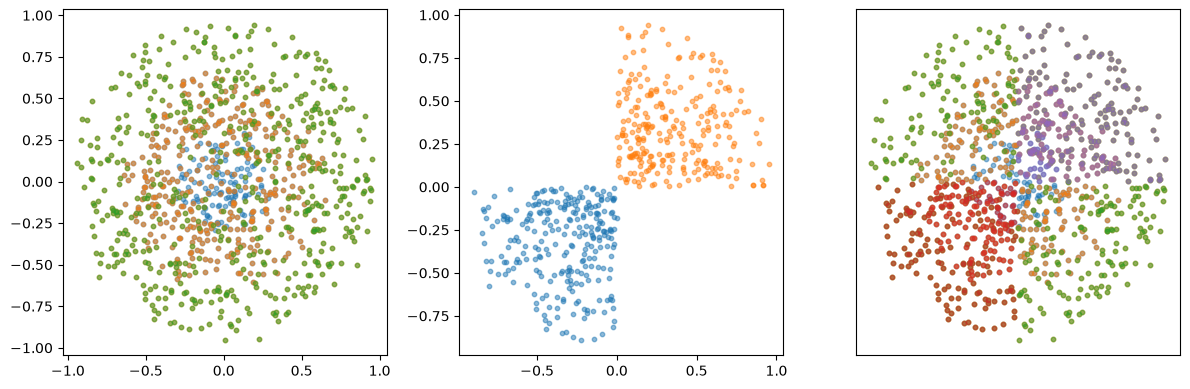

In [135]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].scatter(pt[lab[:,0] == 1, 0], pt[lab[:,0] == 1, 1], s=10, alpha=0.5)
axs[0].scatter(pt[lab[:,1] == 1, 0], pt[lab[:,1] == 1, 1], s=10, alpha=0.5)
axs[0].scatter(pt[lab[:,2] == 1, 0], pt[lab[:,2] == 1, 1], s=10, alpha=0.5)

axs[1].scatter(pt[lab[:,3] == 1, 0], pt[lab[:,3] == 1, 1], s=10, alpha=0.5)
axs[1].scatter(pt[lab[:,4] == 1, 0], pt[lab[:,4] == 1, 1], s=10, alpha=0.5)

axs[2].scatter(pt[lab[:,0] == 1, 0], pt[lab[:,0] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,1] == 1, 0], pt[lab[:,1] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,2] == 1, 0], pt[lab[:,2] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,3] == 1, 0], pt[lab[:,3] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,4] == 1, 0], pt[lab[:,4] == 1, 1], s=10, alpha=0.5)

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

In [ ]:
model, perc_change, stab, loss_history = train_model(42, (16,64,128), n_epochs=100, batch_size=100, amount_data=1000,
                                                      data=multilabel_hypersphere_data, cat100=True, input_dim=2, output_dim=[2,2],
                                                        num_points_per_dim=100, history_limit = 100)